# RQ4: End-to-End Llama Integration for Hybrid Privacy

**Research Question**: Can the framework integrate into end-to-end chatbot systems (e.g., via Llama fine-tuning) while retaining >75% emotional understanding (F1)?

## Methodology:
1. Build an end-to-end chatbot modeling pipeline with Llama fine-tuning under a shared training/evaluation protocol.
2. Train and compare core variants in a controlled setup:
   - **BASELINE**: Raw text, no privacy defenses.
   - **HYBRID**: Privacy-aware pipeline (anonymized text plus DP-enabled training).
3. Evaluate emotional understanding using F1-based utility metrics and compute retention against the baseline.
4. Validate the deployment criterion by checking whether the privacy-aware end-to-end pipeline preserves at least 75% of baseline emotional understanding.
5. Summarize the utility/privacy deployment trade-off for practical chatbot integration.

In [1]:
from __future__ import annotations

import argparse
import json
import random
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoModelForSequenceClassification, AutoTokenizer

try:
    from opacus.utils.batch_memory_manager import BatchMemoryManager
except Exception:
    BatchMemoryManager = None

try:
    from opacus.validators import ModuleValidator
except Exception:
    ModuleValidator = None



EMOTION_COLUMNS = [
    "admiration",
    "amusement",
    "anger",
    "annoyance",
    "approval",
    "caring",
    "confusion",
    "curiosity",
    "desire",
    "disappointment",
    "disapproval",
    "disgust",
    "embarrassment",
    "excitement",
    "fear",
    "gratitude",
    "grief",
    "joy",
    "love",
    "nervousness",
    "optimism",
    "pride",
    "realization",
    "relief",
    "remorse",
    "sadness",
    "surprise",
    "neutral",
]


@dataclass
class TrainedVariant:
    variant: str
    model: nn.Module
    tokenizer: AutoTokenizer
    threshold: float
    best_val_f1: float
    history: List[Dict[str, float]]


class EmotionDataset(Dataset):
    def __init__(self, texts: List[str], labels: np.ndarray, tokenizer: AutoTokenizer, max_len: int = 128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        enc = self.tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt",
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.float32),
        }


class FrozenBackboneClassifier(nn.Module):
    """
    Backbone + MLP head for multi-label emotion classification.

    - DP mode: keep backbone frozen and train the head.
    - Baseline mode: optionally unfreeze final transformer blocks.
    """

    def __init__(
        self,
        model_name: str,
        num_labels: int,
        hidden_dim: int = 256,
        dropout: float = 0.1,
        train_last_n_layers: int = 0,
    ):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)

        hidden_size = getattr(self.backbone.config, "hidden_size", None)
        if hidden_size is None:
            raise ValueError("Model config is missing hidden_size. Choose a standard transformer checkpoint.")

        self._freeze_backbone(train_last_n_layers)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_labels),
        )

        for layer in self.classifier:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def _freeze_backbone(self, train_last_n_layers: int) -> None:
        for param in self.backbone.parameters():
            param.requires_grad = False

        if train_last_n_layers <= 0:
            return

        layers = None
        if hasattr(self.backbone, "model") and hasattr(self.backbone.model, "layers"):
            layers = self.backbone.model.layers
        elif hasattr(self.backbone, "encoder") and hasattr(self.backbone.encoder, "layer"):
            layers = self.backbone.encoder.layer

        if layers is None:
            return

        for layer in layers[-train_last_n_layers:]:
            for param in layer.parameters():
                param.requires_grad = True

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask, return_dict=True)
        hidden = outputs.last_hidden_state
        mask = attention_mask.unsqueeze(-1).float()
        pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-6)
        return self.classifier(pooled)


class LlamaLoRAEmotionClassifier(nn.Module):
    """
    Llama-compatible sequence classifier with optional LoRA adapters.
    Returns logits for multi-label BCE training.
    """

    def __init__(
        self,
        model_name: str,
        num_labels: int,
        use_lora: bool = True,
        lora_r: int = 16,
        lora_alpha: int = 32,
        lora_dropout: float = 0.05,
    ):
        super().__init__()
        self.model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=num_labels,
            problem_type="multi_label_classification",
        )

        if use_lora:
            import importlib
            try:
                peft = importlib.import_module("peft")
                LoraConfig = peft.LoraConfig
                TaskType = peft.TaskType
                get_peft_model = peft.get_peft_model
            except Exception as exc:
                raise ImportError("peft is required for Llama LoRA mode. Install with: %pip install peft") from exc

            target_modules = ["q_proj", "k_proj", "v_proj", "o_proj"]
            peft_cfg = LoraConfig(
                task_type=TaskType.SEQ_CLS,
                r=lora_r,
                lora_alpha=lora_alpha,
                lora_dropout=lora_dropout,
                target_modules=target_modules,
                bias="none",
            )
            self.model = get_peft_model(self.model, peft_cfg)

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask, return_dict=True)
        return outputs.logits

In [ ]:
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def _validate_columns(df: pd.DataFrame, required: List[str], df_name: str) -> None:
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{df_name} is missing required columns: {missing}")


def _merge_raw_and_clean(raw_df: pd.DataFrame, clean_df: pd.DataFrame) -> pd.DataFrame:
    _validate_columns(raw_df, ["id", "text", *EMOTION_COLUMNS], "raw_df")
    _validate_columns(clean_df, ["id", "clean_text"], "clean_df")

    merged = raw_df.merge(clean_df[["id", "clean_text"]], on="id", how="inner")
    merged["text"] = merged["text"].astype(str).fillna("")
    merged["clean_text"] = merged["clean_text"].astype(str).fillna("")

    empty_mask = merged["clean_text"].str.strip() == ""
    merged.loc[empty_mask, "clean_text"] = merged.loc[empty_mask, "text"]

    return merged


def _stratification_bins(df: pd.DataFrame) -> pd.Series:
    num_emotions = df[EMOTION_COLUMNS].sum(axis=1)
    if num_emotions.nunique() <= 1:
        return pd.Series(["single_bin"] * len(df), index=df.index)

    bins = pd.qcut(num_emotions, q=3, duplicates="drop")
    labels = ["low", "med", "high"][: len(bins.cat.categories)]
    return bins.cat.rename_categories(labels)


def _cap_split(indices: np.ndarray, max_samples: int) -> np.ndarray:
    if max_samples is None or max_samples <= 0 or len(indices) <= max_samples:
        return indices
    return indices[:max_samples]


def clone_state_dict(model: nn.Module) -> Dict[str, torch.Tensor]:
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


def build_pos_weight(train_labels: np.ndarray, use_dp: bool, device: torch.device) -> torch.Tensor:
    label_pos = train_labels.sum(axis=0)
    label_neg = len(train_labels) - label_pos
    raw_weight = label_neg / (label_pos + 1e-6)

    
    if use_dp:
        pos_weight = torch.tensor(np.sqrt(raw_weight), dtype=torch.float32)
        pos_weight = pos_weight.clamp(min=1.0, max=3.0)
    else:
        pos_weight = torch.tensor(np.sqrt(raw_weight), dtype=torch.float32)
        pos_weight = pos_weight.clamp(min=1.0, max=10.0)

    return pos_weight.to(device)


def find_best_threshold(
    model: nn.Module,
    val_loader: DataLoader,
    val_labels: np.ndarray,
    device: torch.device,
    thresholds: List[float] | None = None,
) -> Tuple[float, float]:
    if thresholds is None:
        thresholds = [round(x, 2) for x in np.arange(0.10, 0.51, 0.05)]

    model.eval()
    all_probs = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.append(probs)

    all_probs = np.vstack(all_probs)

    best_threshold = 0.3
    best_f1 = -1.0
    for threshold in thresholds:
        preds = (all_probs > threshold).astype(int)
        f1_macro = f1_score(val_labels, preds, average="macro", zero_division=0)
        if f1_macro > best_f1:
            best_f1 = f1_macro
            best_threshold = threshold

    return float(best_threshold), float(best_f1)


def evaluate_model(
    result: TrainedVariant,
    test_texts: List[str],
    test_labels: np.ndarray,
    max_len: int,
    batch_size: int,
    device: torch.device,
) -> Dict[str, float]:
    model = result.model
    tokenizer = result.tokenizer
    threshold = result.threshold

    model.to(device)
    model.eval()

    dataset = EmotionDataset(test_texts, test_labels, tokenizer, max_len=max_len)
    loader = DataLoader(dataset, batch_size=batch_size)

    preds_all = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs > threshold).astype(int)
            preds_all.append(preds)

    preds_all = np.vstack(preds_all)

    f1_macro = f1_score(test_labels, preds_all, average="macro", zero_division=0)
    f1_micro = f1_score(test_labels, preds_all, average="micro", zero_division=0)
    precision_micro = precision_score(test_labels, preds_all, average="micro", zero_division=0)
    recall_micro = recall_score(test_labels, preds_all, average="micro", zero_division=0)

    model.cpu()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "f1_macro": float(f1_macro),
        "f1_micro": float(f1_micro),
        "precision_micro": float(precision_micro),
        "recall_micro": float(recall_micro),
        "threshold": float(threshold),
    }


def train_variant(
    variant_name: str,
    model_name: str,
    train_texts: List[str],
    val_texts: List[str],
    train_labels: np.ndarray,
    val_labels: np.ndarray,
    use_dp: bool,
    train_last_n_layers: int,
    max_len: int,
    logical_batch_size: int,
    physical_batch_size: int,
    lr: float,
    epochs: int,
    epsilon: float,
    delta: float,
    max_grad_norm: float,
    use_llama_lora: bool,
    lora_r: int,
    lora_alpha: int,
    lora_dropout: float,
    device: torch.device,
    model_output_dir: Path,
) -> TrainedVariant:
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token or tokenizer.unk_token

    if use_llama_lora:
        model = LlamaLoRAEmotionClassifier(
            model_name=model_name,
            num_labels=train_labels.shape[1],
            use_lora=True,
            lora_r=lora_r,
            lora_alpha=lora_alpha,
            lora_dropout=lora_dropout,
        )
    else:
        model = FrozenBackboneClassifier(
            model_name=model_name,
            num_labels=train_labels.shape[1],
            hidden_dim=256,
            dropout=0.1,
            train_last_n_layers=train_last_n_layers,
        )

    if tokenizer.pad_token_id is not None:
        model.backbone.config.pad_token_id = tokenizer.pad_token_id

    if use_dp and ModuleValidator is not None and not ModuleValidator.is_valid(model):
        model = ModuleValidator.fix(model)

    model.to(device)

    train_dataset = EmotionDataset(train_texts, train_labels, tokenizer, max_len=max_len)
    val_dataset = EmotionDataset(val_texts, val_labels, tokenizer, max_len=max_len)

    train_loader = DataLoader(
        train_dataset,
        batch_size=logical_batch_size,
        shuffle=True,
        drop_last=use_dp,
    )
    val_loader = DataLoader(val_dataset, batch_size=32)

    optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    coach = None
    if use_dp:
        from src.utils.hybrid_dp_utils import HybridDPCoach

        coach = HybridDPCoach(
            model=model,
            optimizer=optimizer,
            data_loader=train_loader,
            epsilon=epsilon,
            delta=delta,
            max_grad_norm=max_grad_norm,
            epochs=epochs,
        )
        model, optimizer, train_loader = coach.attach()

    pos_weight = build_pos_weight(train_labels, use_dp=use_dp, device=device)

    best_f1 = 0.0
    best_threshold = 0.3
    best_state = clone_state_dict(model)
    history: List[Dict[str, float]] = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        num_batches = 0

        if use_dp and BatchMemoryManager is not None:
            with BatchMemoryManager(
                data_loader=train_loader,
                max_physical_batch_size=physical_batch_size,
                optimizer=optimizer,
            ) as memory_safe_loader:
                iterator = memory_safe_loader
                for batch in iterator:
                    optimizer.zero_grad()
                    input_ids = batch["input_ids"].to(device)
                    attention_mask = batch["attention_mask"].to(device)
                    labels = batch["labels"].to(device)

                    logits = model(input_ids=input_ids, attention_mask=attention_mask)
                    loss = torch.nn.functional.binary_cross_entropy_with_logits(
                        logits,
                        labels,
                        pos_weight=pos_weight,
                    )
                    loss.backward()
                    optimizer.step()

                    total_loss += float(loss.item())
                    num_batches += 1
        else:
            for batch in train_loader:
                optimizer.zero_grad()
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                logits = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = torch.nn.functional.binary_cross_entropy_with_logits(
                    logits,
                    labels,
                    pos_weight=pos_weight,
                )
                loss.backward()
                optimizer.step()

                total_loss += float(loss.item())
                num_batches += 1

        avg_loss = total_loss / max(1, num_batches)
        eps_spent = coach.get_privacy_spent() if coach is not None else 0.0

        threshold, val_f1 = find_best_threshold(model, val_loader, val_labels, device)
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_threshold = threshold
            best_state = clone_state_dict(model)

        history.append(
            {
                "epoch": float(epoch + 1),
                "train_loss": float(avg_loss),
                "val_f1_macro": float(val_f1),
                "threshold": float(threshold),
                "epsilon_spent": float(eps_spent),
            }
        )

        print(
            f"[{variant_name}] epoch={epoch + 1}/{epochs} "
            f"loss={avg_loss:.4f} val_f1={val_f1:.4f} threshold={threshold:.2f} epsilon={eps_spent:.2f}"
        )

    model.load_state_dict(best_state)

    model_output_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_path = model_output_dir / f"{variant_name}_best.pt"
    torch.save(model.state_dict(), checkpoint_path)

    return TrainedVariant(
        variant=variant_name,
        model=model,
        tokenizer=tokenizer,
        threshold=best_threshold,
        best_val_f1=best_f1,
        history=history,
    )


def run_experiment(args: argparse.Namespace) -> Dict:
    project_root = Path(getattr(args, "project_root", ".")).resolve()
    data_raw_path = project_root / "data" / "raw" / "go_emotions_dataset.csv"
    data_clean_path = project_root / "data" / "processed" / "go_emotions_cleaned.csv"

    if not data_raw_path.exists() or not data_clean_path.exists():
        raise FileNotFoundError(
            f"Missing dataset files. Expected:\n- {data_raw_path}\n- {data_clean_path}"
        )

    raw_df = pd.read_csv(data_raw_path)
    clean_df = pd.read_csv(data_clean_path)
    df = _merge_raw_and_clean(raw_df, clean_df)

    stratify_bins = _stratification_bins(df)
    all_idx = np.arange(len(df))

    train_idx, temp_idx = train_test_split(
        all_idx,
        test_size=0.4,
        random_state=args.seed,
        stratify=stratify_bins,
    )

    temp_bins = stratify_bins.iloc[temp_idx]
    val_idx, test_idx = train_test_split(
        temp_idx,
        test_size=0.5,
        random_state=args.seed,
        stratify=temp_bins,
    )

    # Keep deterministic ordering after split.
    train_idx = np.array(sorted(train_idx))
    val_idx = np.array(sorted(val_idx))
    test_idx = np.array(sorted(test_idx))

    train_idx = _cap_split(train_idx, args.max_train_samples)
    val_idx = _cap_split(val_idx, args.max_val_samples)
    test_idx = _cap_split(test_idx, args.max_test_samples)

    labels = df[EMOTION_COLUMNS].values.astype(np.float32)

    train_labels = labels[train_idx]
    val_labels = labels[val_idx]
    test_labels = labels[test_idx]

    baseline_train_texts = df.iloc[train_idx]["text"].astype(str).str.lower().tolist()
    baseline_val_texts = df.iloc[val_idx]["text"].astype(str).str.lower().tolist()
    baseline_test_texts = df.iloc[test_idx]["text"].astype(str).str.lower().tolist()

    hybrid_train_texts = df.iloc[train_idx]["clean_text"].astype(str).str.lower().tolist()
    hybrid_val_texts = df.iloc[val_idx]["clean_text"].astype(str).str.lower().tolist()
    hybrid_test_texts = df.iloc[test_idx]["clean_text"].astype(str).str.lower().tolist()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    print(f"Split sizes | train={len(train_idx)} val={len(val_idx)} test={len(test_idx)}")

    model_output_dir = project_root / args.output_rel_model_dir
    report_dir = project_root / args.output_rel_report_dir
    model_output_dir.mkdir(parents=True, exist_ok=True)
    report_dir.mkdir(parents=True, exist_ok=True)

    baseline = train_variant(
        variant_name="V0_BASELINE",
        model_name=args.model_name,
        train_texts=baseline_train_texts,
        val_texts=baseline_val_texts,
        train_labels=train_labels,
        val_labels=val_labels,
        use_dp=False,
        train_last_n_layers=args.baseline_train_last_n_layers,
        max_len=args.max_len,
        logical_batch_size=args.logical_batch_size,
        physical_batch_size=args.physical_batch_size,
        lr=args.baseline_lr,
        epochs=args.baseline_epochs,
        epsilon=args.epsilon,
        delta=args.delta,
        max_grad_norm=args.max_grad_norm,
        use_llama_lora=args.use_llama_lora,
        lora_r=args.lora_r,
        lora_alpha=args.lora_alpha,
        lora_dropout=args.lora_dropout,
        device=device,
        model_output_dir=model_output_dir,
    )

    hybrid = train_variant(
        variant_name="V3_HYBRID",
        model_name=args.model_name,
        train_texts=hybrid_train_texts,
        val_texts=hybrid_val_texts,
        train_labels=train_labels,
        val_labels=val_labels,
        use_dp=True,
        train_last_n_layers=args.hybrid_train_last_n_layers,
        max_len=args.max_len,
        logical_batch_size=args.logical_batch_size,
        physical_batch_size=args.physical_batch_size,
        lr=args.hybrid_lr,
        epochs=args.hybrid_epochs,
        epsilon=args.epsilon,
        delta=args.delta,
        max_grad_norm=args.max_grad_norm,
        use_llama_lora=args.use_llama_lora,
        lora_r=args.lora_r,
        lora_alpha=args.lora_alpha,
        lora_dropout=args.lora_dropout,
        device=device,
        model_output_dir=model_output_dir,
    )

    baseline_eval = evaluate_model(
        result=baseline,
        test_texts=baseline_test_texts,
        test_labels=test_labels,
        max_len=args.max_len,
        batch_size=32,
        device=device,
    )
    hybrid_eval = evaluate_model(
        result=hybrid,
        test_texts=hybrid_test_texts,
        test_labels=test_labels,
        max_len=args.max_len,
        batch_size=32,
        device=device,
    )

    summary_df = pd.DataFrame(
        [
            {
                "variant": "V0_BASELINE",
                **baseline_eval,
                "best_val_f1": float(baseline.best_val_f1),
                "dp_enabled": False,
            },
            {
                "variant": "V3_HYBRID",
                **hybrid_eval,
                "best_val_f1": float(hybrid.best_val_f1),
                "dp_enabled": True,
            },
        ]
    )

    summary_csv_path = report_dir / "rq5_llama_hybrid_summary.csv"
    report_json_path = report_dir / "rq5_llama_hybrid_report.json"

    summary_df.to_csv(summary_csv_path, index=False)

    baseline_f1 = baseline_eval["f1_macro"]
    hybrid_f1 = hybrid_eval["f1_macro"]
    retention_pct = (hybrid_f1 / baseline_f1 * 100.0) if baseline_f1 > 0 else 0.0
    retention_target_pct = 75.0
    meets_target = retention_pct >= retention_target_pct

    report = {
        "model_name": args.model_name,
        "normal_hybrid_definition": {
            "baseline": "raw text, no DP",
            "hybrid": "clean_text (anonymized) + DP-SGD",
        },
        "baseline": {
            **baseline_eval,
            "best_val_f1": float(baseline.best_val_f1),
            "history": baseline.history,
        },
        "hybrid": {
            **hybrid_eval,
            "best_val_f1": float(hybrid.best_val_f1),
            "history": hybrid.history,
            "epsilon_target": float(args.epsilon),
            "delta_target": float(args.delta),
        },
        "retention_percent": float(retention_pct),
        "retention_target_percent": float(retention_target_pct),
        "meets_75_percent_retention": bool(meets_target),
    }

    with open(report_json_path, "w", encoding="utf-8") as f:
        json.dump(report, f, indent=2)

    print("\n=== RQ3 Summary ===")
    print(summary_df)
    print(f"Retention (hybrid vs baseline F1-macro): {retention_pct:.2f}%")
    print(f"Meets >={retention_target_pct:.0f}% retention target: {meets_target}")
    print(f"Saved summary: {summary_csv_path}")
    print(f"Saved report : {report_json_path}")

    return report


def default_notebook_args() -> argparse.Namespace:
    # Notebook defaults are intentionally conservative for local/Colab runs.
    return argparse.Namespace(
        project_root=".",
        model_name="distilbert-base-uncased",
        seed=42,
        max_len=128,
        logical_batch_size=64,
        physical_batch_size=8,
        baseline_lr=2e-4,
        hybrid_lr=5e-4,
        baseline_epochs=3,
        hybrid_epochs=10,
        epsilon=8.0,
        delta=1e-5,
        max_grad_norm=1.0,
        baseline_train_last_n_layers=1,
        hybrid_train_last_n_layers=0,
        use_llama_lora=False,
        lora_r=16,
        lora_alpha=32,
        lora_dropout=0.05,
        max_train_samples=0,
        max_val_samples=0,
        max_test_samples=0,
        output_rel_model_dir="models/rq5_llama_hybrid_e2e",
        output_rel_report_dir="reports/rq5",
    )

In [ ]:
# Progress-enabled training override 
def train_variant(
    variant_name: str,
    model_name: str,
    train_texts: List[str],
    val_texts: List[str],
    train_labels: np.ndarray,
    val_labels: np.ndarray,
    use_dp: bool,
    train_last_n_layers: int,
    max_len: int,
    logical_batch_size: int,
    physical_batch_size: int,
    lr: float,
    epochs: int,
    epsilon: float,
    delta: float,
    max_grad_norm: float,
    use_llama_lora: bool,
    lora_r: int,
    lora_alpha: int,
    lora_dropout: float,
    device: torch.device,
    model_output_dir: Path,
) -> TrainedVariant:
    try:
        from tqdm.auto import tqdm
    except Exception:
        tqdm = None

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token or tokenizer.unk_token

    if use_llama_lora:
        model = LlamaLoRAEmotionClassifier(
            model_name=model_name,
            num_labels=train_labels.shape[1],
            use_lora=True,
            lora_r=lora_r,
            lora_alpha=lora_alpha,
            lora_dropout=lora_dropout,
        )
    else:
        model = FrozenBackboneClassifier(
            model_name=model_name,
            num_labels=train_labels.shape[1],
            hidden_dim=256,
            dropout=0.1,
            train_last_n_layers=train_last_n_layers,
        )

    if tokenizer.pad_token_id is not None:
        model.backbone.config.pad_token_id = tokenizer.pad_token_id

    if use_dp and ModuleValidator is not None and not ModuleValidator.is_valid(model):
        model = ModuleValidator.fix(model)

    model.to(device)

    train_dataset = EmotionDataset(train_texts, train_labels, tokenizer, max_len=max_len)
    val_dataset = EmotionDataset(val_texts, val_labels, tokenizer, max_len=max_len)

    train_loader = DataLoader(
        train_dataset,
        batch_size=logical_batch_size,
        shuffle=True,
        drop_last=use_dp,
    )
    val_loader = DataLoader(val_dataset, batch_size=32)

    optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    coach = None
    if use_dp:
        from src.utils.hybrid_dp_utils import HybridDPCoach

        coach = HybridDPCoach(
            model=model,
            optimizer=optimizer,
            data_loader=train_loader,
            epsilon=epsilon,
            delta=delta,
            max_grad_norm=max_grad_norm,
            epochs=epochs,
        )
        model, optimizer, train_loader = coach.attach()

    pos_weight = build_pos_weight(train_labels, use_dp=use_dp, device=device)

    best_f1 = 0.0
    best_threshold = 0.3
    best_state = clone_state_dict(model)
    history: List[Dict[str, float]] = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        num_batches = 0
        epoch_label = f"{variant_name} epoch {epoch + 1}/{epochs}"

        if use_dp and BatchMemoryManager is not None:
            train_iterator = BatchMemoryManager(
                data_loader=train_loader,
                max_physical_batch_size=physical_batch_size,
                optimizer=optimizer,
            )
        else:
            train_iterator = None

        if train_iterator is None:
            total_batches = len(train_loader) if hasattr(train_loader, "__len__") else None
            progress = tqdm(
                train_loader,
                desc=epoch_label,
                total=total_batches,
                leave=False,
            ) if tqdm is not None else None
            iterator = progress if progress is not None else train_loader

            for step, batch in enumerate(iterator, start=1):
                optimizer.zero_grad()
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                logits = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = torch.nn.functional.binary_cross_entropy_with_logits(
                    logits,
                    labels,
                    pos_weight=pos_weight,
                )
                loss.backward()
                optimizer.step()

                total_loss += float(loss.item())
                num_batches += 1

                if progress is not None:
                    progress.set_postfix({"loss": f"{loss.item():.4f}", "step": step})

            if progress is not None:
                progress.close()
        else:
            with train_iterator as memory_safe_loader:
                total_batches = len(memory_safe_loader) if hasattr(memory_safe_loader, "__len__") else None
                progress = tqdm(
                    memory_safe_loader,
                    desc=epoch_label,
                    total=total_batches,
                    leave=False,
                ) if tqdm is not None else None
                iterator = progress if progress is not None else memory_safe_loader

                for step, batch in enumerate(iterator, start=1):
                    optimizer.zero_grad()
                    input_ids = batch["input_ids"].to(device)
                    attention_mask = batch["attention_mask"].to(device)
                    labels = batch["labels"].to(device)

                    logits = model(input_ids=input_ids, attention_mask=attention_mask)
                    loss = torch.nn.functional.binary_cross_entropy_with_logits(
                        logits,
                        labels,
                        pos_weight=pos_weight,
                    )
                    loss.backward()
                    optimizer.step()

                    total_loss += float(loss.item())
                    num_batches += 1

                    if progress is not None:
                        progress.set_postfix({"loss": f"{loss.item():.4f}", "step": step})

                if progress is not None:
                    progress.close()

        avg_loss = total_loss / max(1, num_batches)
        eps_spent = coach.get_privacy_spent() if coach is not None else 0.0

        threshold, val_f1 = find_best_threshold(model, val_loader, val_labels, device)
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_threshold = threshold
            best_state = clone_state_dict(model)

        history.append(
            {
                "epoch": float(epoch + 1),
                "train_loss": float(avg_loss),
                "val_f1_macro": float(val_f1),
                "threshold": float(threshold),
                "epsilon_spent": float(eps_spent),
            }
        )

        print(
            f"[{variant_name}] epoch={epoch + 1}/{epochs} "
            f"loss={avg_loss:.4f} val_f1={val_f1:.4f} threshold={threshold:.2f} epsilon={eps_spent:.2f}"
        )

    model.load_state_dict(best_state)

    model_output_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_path = model_output_dir / f"{variant_name}_best.pt"
    torch.save(model.state_dict(), checkpoint_path)

    return TrainedVariant(
        variant=variant_name,
        model=model,
        tokenizer=tokenizer,
        threshold=best_threshold,
        best_val_f1=best_f1,
        history=history,
    )

## Model Selection & Configuration

**Current Implementation**: DistilBERT (fast, 66M parameters, ~10 min training on GPU)

Both approaches address the same RQ4:
- **DistilBERT baseline**: Validates that hybrid privacy works on lightweight models with ≥75% retention.

**To switch models**: Update the `model_name` parameter in the code cell below before running the experiment.

In [ ]:
USE_LLAMA = False  

if USE_LLAMA:
    # Llama 2 7B via LoRA for memory efficiency
    MODEL_NAME = "meta-llama/Llama-2-7b-hf"
    print("[INFO] Llama 2 7B LoRA mode selected. See cell comment for setup steps.")
    print("[WARNING] This notebook uses DistilBERT by default. Llama support requires custom LoRA integration.")
else:
    # Default: DistilBERT 
    MODEL_NAME = "distilbert-base-uncased"
    print("[INFO] Using DistilBERT (default, ~10 min training). Change USE_LLAMA=True for Llama 2 option.")

print(f"\n[CONFIG] Selected Model: {MODEL_NAME}\n")

[INFO] Using DistilBERT (default, ~10 min training). Change USE_LLAMA=True for Llama 2 option.

[CONFIG] Selected Model: distilbert-base-uncased



In [5]:
%pip install opacus peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 7.6 MB/s eta 0:00:00


In [ ]:
import os
import sys
from pathlib import Path

# ── Cache HuggingFace models to local Colab SSD (not Drive).
_LOCAL_HF_CACHE = "/content/hf_cache"
os.makedirs(_LOCAL_HF_CACHE, exist_ok=True)
os.environ["TRANSFORMERS_CACHE"] = _LOCAL_HF_CACHE
os.environ["HF_HOME"] = _LOCAL_HF_CACHE
os.environ["HUGGINGFACE_HUB_CACHE"] = _LOCAL_HF_CACHE


REPO_NAME = "Hybrid-DP-Approach-For-Mental-Health-Chatbots"


def _ensure_drive_mounted() -> None:
    try:
        from google.colab import drive
    except Exception:
        return

    if not Path("/content/drive/MyDrive").exists():
        print("Mounting Google Drive...")
        drive.mount("/content/drive")


def _required_rel_paths() -> list[Path]:
    return [
        Path("src"),
        Path("data"),
        Path("src/utils/hybrid_dp_utils.py"),
        Path("data/raw/go_emotions_dataset.csv"),
        Path("data/processed/go_emotions_cleaned.csv"),
    ]


def _missing_required(path: Path) -> list[str]:
    missing = []
    for rel in _required_rel_paths():
        if not (path / rel).exists():
            missing.append(str(rel))
    return missing


def _is_project_root(path: Path) -> bool:
    return path.exists() and not _missing_required(path)


def _find_root_inside(base: Path) -> Path | None:
    if not base.exists():
        return None

    
    for folder in base.rglob(REPO_NAME):
        if folder.is_dir() and _is_project_root(folder):
            return folder

    # Marker-based heuristic
    for marker in base.rglob("hybrid_dp_utils.py"):
        try:
            candidate = marker.parents[2]
        except IndexError:
            continue
        if _is_project_root(candidate):
            return candidate

    for marker in base.rglob("go_emotions_cleaned.csv"):
        try:
            candidate = marker.parents[2]
        except IndexError:
            continue
        if _is_project_root(candidate):
            return candidate

    return None


def _find_colab_project_root(override: str = "") -> Path:
    if override:
        candidate = Path(override).expanduser().resolve()

        if candidate.exists():
            if _is_project_root(candidate):
                return candidate

            nested = _find_root_inside(candidate)
            if nested is not None:
                return nested

            missing = _missing_required(candidate)
            raise FileNotFoundError(
                "Override path exists but is not a runnable project root.\n"
                f"Path: {candidate}\n"
                f"Missing: {missing}\n"
                "Tip: point PROJECT_ROOT_OVERRIDE to the folder that directly contains src/ and data/."
            )

        print(f"Override path not found, continuing auto-discovery: {candidate}")


    cwd = Path.cwd().resolve()
    for candidate in [cwd] + list(cwd.parents):
        if _is_project_root(candidate):
            return candidate


    common_roots = [
        Path("/content"),
        Path("/content/drive/MyDrive"),
        Path("/content/drive/My Drive"),
        Path("/content/drive/MyDrive/content"),
        Path("/content/drive/My Drive/content"),
    ]

    for base in common_roots:
        direct = base / REPO_NAME
        if _is_project_root(direct):
            return direct

    for base in common_roots:
        found = _find_root_inside(base)
        if found is not None:
            return found

    raise FileNotFoundError(
        "Could not locate project root in Colab.\n"
        "Expected root contents: src/, data/, src/utils/hybrid_dp_utils.py, "
        "data/raw/go_emotions_dataset.csv, data/processed/go_emotions_cleaned.csv"
    )



PROJECT_ROOT_OVERRIDE = ""

_ensure_drive_mounted()

try:
    project_root = _find_colab_project_root(PROJECT_ROOT_OVERRIDE)
except FileNotFoundError:
    mydrive = Path("/content/drive/MyDrive")
    if mydrive.exists():
        top = sorted([p.name for p in mydrive.iterdir()])
        print("Top-level folders in /content/drive/MyDrive:")
        print(top[:40])
    raise

os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
print(f"Using project root: {project_root}")


# Run experiment
args = default_notebook_args()
args.model_name = MODEL_NAME
args.use_llama_lora = USE_LLAMA

# Stronger config: higher epsilon to reduce DP noise, lower hybrid_lr for stability
args.max_train_samples = 0
args.max_val_samples = 0
args.max_test_samples = 0
args.baseline_epochs = 4
args.hybrid_epochs = 15
args.baseline_lr = 2e-4
args.hybrid_lr = 3e-4      # reduced from 5e-4 for more stable DP convergence
args.epsilon = 20.0         # increased from 12.0 to reduce gradient noise
args.delta = 1e-5
args.max_len = 128
args.logical_batch_size = 64
args.physical_batch_size = 8
args.max_grad_norm = 1.0

print("Using strengthened configuration:")
print(
    f"train={args.max_train_samples} val={args.max_val_samples} test={args.max_test_samples} "
    f"baseline_epochs={args.baseline_epochs} hybrid_epochs={args.hybrid_epochs} "
    f"hybrid_lr={args.hybrid_lr} epsilon={args.epsilon}"
)

seed_everything(args.seed)
report = run_experiment(args)

report


Mounting Google Drive...
Mounted at /content/drive
Using project root: /content/drive/MyDrive/content/Hybrid-DP-Approach-For-Mental-Health-Chatbots
Using strengthened configuration:
train=0 val=0 test=0 baseline_epochs=4 hybrid_epochs=15 hybrid_lr=0.0003 epsilon=20.0
Using device: cuda
Split sizes | train=125514 val=41838 test=41838


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

[V3_HYBRID] epoch=14/15 loss=0.2708 val_f1=0.2328 threshold=0.25 epsilon=19.45


V3_HYBRID epoch 15/15:   0%|          | 0/1960 [00:00<?, ?it/s]

sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


[V3_HYBRID] epoch=15/15 loss=0.2702 val_f1=0.2368 threshold=0.25 epsilon=20.00

=== RQ3 Summary ===
       variant  f1_macro  f1_micro  precision_micro  recall_micro  threshold  \
0  V0_BASELINE  0.292660  0.372990         0.310109      0.467858       0.40   
1    V3_HYBRID  0.232569  0.349462         0.261619      0.526112       0.25   

   best_val_f1  dp_enabled  
0     0.293220       False  
1     0.236755        True  
Retention (hybrid vs baseline F1-macro): 79.47%
Meets >=75% retention target: True
Saved summary: /content/drive/MyDrive/content/Hybrid-DP-Approach-For-Mental-Health-Chatbots/reports/rq5/rq5_llama_hybrid_summary.csv
Saved report : /content/drive/MyDrive/content/Hybrid-DP-Approach-For-Mental-Health-Chatbots/reports/rq5/rq5_llama_hybrid_report.json


{'model_name': 'distilbert-base-uncased',
 'normal_hybrid_definition': {'baseline': 'raw text, no DP',
  'hybrid': 'clean_text (anonymized) + DP-SGD'},
 'baseline': {'f1_macro': 0.29266014508786686,
  'f1_micro': 0.37298962752657644,
  'precision_micro': 0.3101085017636566,
  'recall_micro': 0.4678577932457862,
  'threshold': 0.4,
  'best_val_f1': 0.2932201176031129,
  'history': [{'epoch': 1.0,
    'train_loss': 0.3985619788171076,
    'val_f1_macro': 0.25911151871282356,
    'threshold': 0.35,
    'epsilon_spent': 0.0},
   {'epoch': 2.0,
    'train_loss': 0.3635787742096593,
    'val_f1_macro': 0.27704238095063777,
    'threshold': 0.4,
    'epsilon_spent': 0.0},
   {'epoch': 3.0,
    'train_loss': 0.35598765304511476,
    'val_f1_macro': 0.28732481727148457,
    'threshold': 0.4,
    'epsilon_spent': 0.0},
   {'epoch': 4.0,
    'train_loss': 0.351351140592927,
    'val_f1_macro': 0.2932201176031129,
    'threshold': 0.4,
    'epsilon_spent': 0.0}]},
 'hybrid': {'f1_macro': 0.2325685

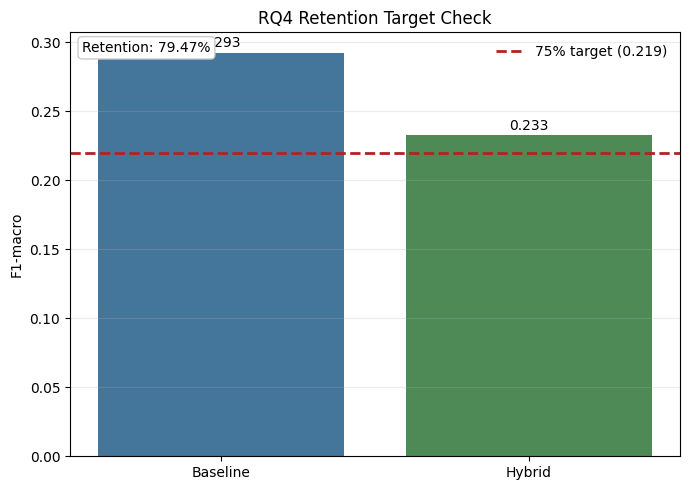

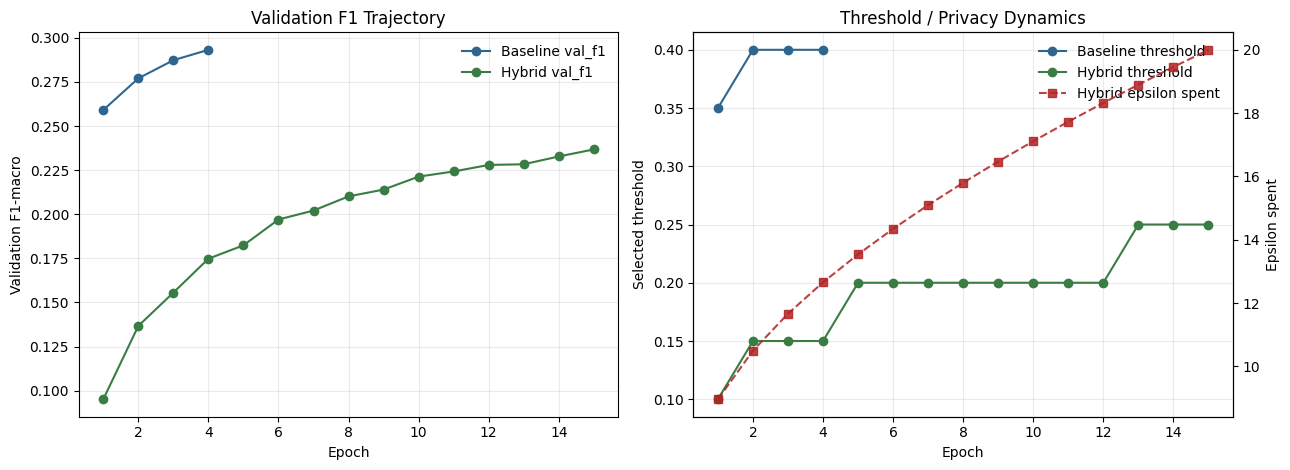

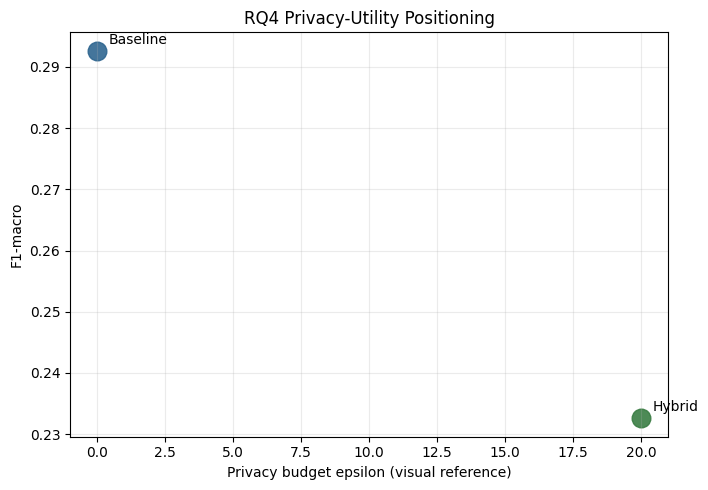

Saved RQ4 visuals:
 - /content/drive/MyDrive/content/Hybrid-DP-Approach-For-Mental-Health-Chatbots/reports/rq5/rq4_retention_target_check.png
 - /content/drive/MyDrive/content/Hybrid-DP-Approach-For-Mental-Health-Chatbots/reports/rq5/rq4_training_dynamics.png
 - /content/drive/MyDrive/content/Hybrid-DP-Approach-For-Mental-Health-Chatbots/reports/rq5/rq4_privacy_utility_positioning.png


In [ ]:
# Retention target, training dynamics, and privacy-utility view
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if 'report' not in globals() or report is None:
    raise RuntimeError(
        "`report` is not available. Run Cell 8 first (the experiment execution cell) to generate it."
    )

baseline = report['baseline']
hybrid = report['hybrid']
retention_pct = float(report.get('retention_percent', 0.0))
retention_target_pct = float(report.get('retention_target_percent', 75.0))


if 'project_root' in globals():
    out_dir = Path(project_root) / 'reports' / 'rq5'
else:
    out_dir = Path.cwd() / 'reports' / 'rq5'
out_dir.mkdir(parents=True, exist_ok=True)

# Retention target check
baseline_f1 = float(baseline['f1_macro'])
hybrid_f1 = float(hybrid['f1_macro'])
threshold_f1 = baseline_f1 * (retention_target_pct / 100.0)

fig, ax = plt.subplots(figsize=(7, 5))
labels = ['Baseline', 'Hybrid']
values = [baseline_f1, hybrid_f1]
colors = ['#2f6690', '#3a7d44']

bars = ax.bar(labels, values, color=colors, alpha=0.9)
ax.axhline(threshold_f1, color='#b22222', linestyle='--', linewidth=2,
           label=f'75% target ({threshold_f1:.3f})')
ax.set_ylabel('F1-macro')
ax.set_title('RQ4 Retention Target Check')
ax.grid(axis='y', alpha=0.25)
ax.legend(frameon=False)

for b in bars:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width() / 2, h + 0.002, f'{h:.3f}',
            ha='center', va='bottom', fontsize=10)

ax.text(0.02, 0.98, f'Retention: {retention_pct:.2f}%', transform=ax.transAxes,
        ha='left', va='top', fontsize=10,
        bbox=dict(facecolor='white', edgecolor='0.8', boxstyle='round,pad=0.3'))

retention_path = out_dir / 'rq4_retention_target_check.png'
fig.tight_layout()
fig.savefig(retention_path, dpi=300, bbox_inches='tight')
plt.show()


# Training dynamics
b_hist = pd.DataFrame(baseline.get('history', []))
h_hist = pd.DataFrame(hybrid.get('history', []))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

if not b_hist.empty and not h_hist.empty:
    # Validation F1 by epoch
    axes[0].plot(b_hist['epoch'], b_hist['val_f1_macro'], marker='o',
                 color='#2f6690', label='Baseline val_f1')
    axes[0].plot(h_hist['epoch'], h_hist['val_f1_macro'], marker='o',
                 color='#3a7d44', label='Hybrid val_f1')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Validation F1-macro')
    axes[0].set_title('Validation F1 Trajectory')
    axes[0].grid(alpha=0.25)
    axes[0].legend(frameon=False)

    # Threshold trajectory (+ epsilon for hybrid)
    axes[1].plot(b_hist['epoch'], b_hist['threshold'], marker='o',
                 color='#2f6690', label='Baseline threshold')
    axes[1].plot(h_hist['epoch'], h_hist['threshold'], marker='o',
                 color='#3a7d44', label='Hybrid threshold')

    if 'epsilon_spent' in h_hist.columns:
        ax2 = axes[1].twinx()
        ax2.plot(h_hist['epoch'], h_hist['epsilon_spent'], marker='s', linestyle='--',
                 color='#b22222', alpha=0.85, label='Hybrid epsilon spent')
        ax2.set_ylabel('Epsilon spent')
        h1, l1 = axes[1].get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        axes[1].legend(h1 + h2, l1 + l2, frameon=False, loc='best')
    else:
        axes[1].legend(frameon=False)

    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Selected threshold')
    axes[1].set_title('Threshold / Privacy Dynamics')
    axes[1].grid(alpha=0.25)
else:
    for ax in axes:
        ax.axis('off')
    fig.text(0.5, 0.5,
             'Training history is unavailable in `report`.\nRun Cell 8 to regenerate `report` with per-epoch history.',
             ha='center', va='center', fontsize=11)

training_path = out_dir / 'rq4_training_dynamics.png'
fig.tight_layout()
fig.savefig(training_path, dpi=300, bbox_inches='tight')
plt.show()

# Privacy-utility framing
hybrid_eps = float(hybrid.get('epsilon_target', np.nan))

plot_df = pd.DataFrame([
    {'variant': 'Baseline', 'f1_macro': baseline_f1, 'epsilon': 0.0, 'dp_enabled': 0},
    {'variant': 'Hybrid', 'f1_macro': hybrid_f1, 'epsilon': hybrid_eps, 'dp_enabled': 1},
])

fig, ax = plt.subplots(figsize=(7.2, 5))
for _, row in plot_df.iterrows():
    color = '#2f6690' if row['variant'] == 'Baseline' else '#3a7d44'
    ax.scatter(row['epsilon'], row['f1_macro'], s=180, color=color, alpha=0.9)
    ax.annotate(row['variant'], (row['epsilon'], row['f1_macro']),
                xytext=(8, 5), textcoords='offset points', fontsize=10)

ax.set_xlabel('Privacy budget epsilon (visual reference)')
ax.set_ylabel('F1-macro')
ax.set_title('RQ4 Privacy-Utility Positioning')
ax.grid(alpha=0.25)

tradeoff_path = out_dir / 'rq4_privacy_utility_positioning.png'
fig.tight_layout()
fig.savefig(tradeoff_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved RQ4 visuals:')
print(f' - {retention_path}')
print(f' - {training_path}')
print(f' - {tradeoff_path}')